<a href="https://colab.research.google.com/github/sahanapatil2209/data-science-projects/blob/main/House_loan_data_analysis/Home_loan_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project focuses on predicting loan default risk using historical applicant data. The objective is to build machine learning models that can accurately classify whether a loan applicant is likely to repay or default. The dataset contains a wide range of demographic, financial, and behavioral features, making it suitable for applying both deep learning and advanced machine learning techniques.

Due to the highly imbalanced nature of the dataset, special attention is given to preprocessing, feature engineering, and evaluation metrics that prioritize the identification of high risk applicants. Models such as Artificial Neural Networks and XGBoost are implemented and compared to determine the most effective approach for credit risk prediction.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

In [44]:
# 1. LOAD DATA
# =========================
df = pd.read_csv("loan_data.csv")

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape of dataset: (307511, 122)

First 5 rows:
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUM

In [45]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

print("\nColumns with null values:")
print(null_counts)



Columns with null values:
COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
                             ...  
EXT_SOURCE_2                   660
AMT_GOODS_PRICE                278
AMT_ANNUITY                     12
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 67, dtype: int64



Target counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentages:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


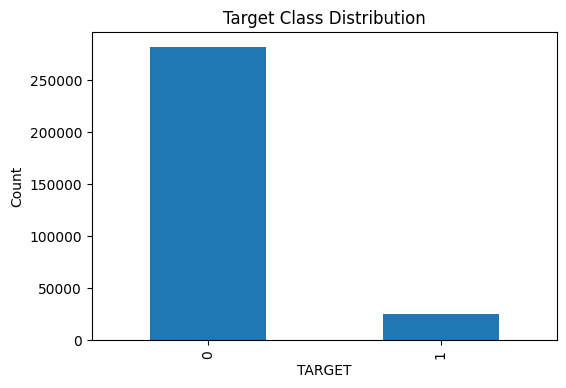

In [46]:
target_counts = df["TARGET"].value_counts()
target_percent = df["TARGET"].value_counts(normalize=True) * 100

print("\nTarget counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percent)

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.show()

In [47]:
X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

In [48]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nNumber of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))


Number of categorical columns: 16
Number of numerical columns: 104


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (246008, 120)
Test shape: (61503, 120)


In [50]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [51]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [52]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed for ANN
X_train_processed = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_processed = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

print("\nProcessed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed train shape: (246008, 244)
Processed test shape: (61503, 244)


In [12]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {cls: weight for cls, weight in zip(classes, class_weights_array)}

print("\nClass weights:")
print(class_weights)


Class weights:
{np.int64(0): np.float64(0.5439092983356032), np.int64(1): np.float64(6.193554884189325)}


In [53]:
input_dim = X_train_processed.shape[1]

model = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        31,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,497 (166.00 KB)

 Trainable params: 42,113 (164.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [54]:
early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)


In [55]:
history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6191 - auc: 0.6779 - loss: 0.6603 - val_accuracy: 0.6869 - val_auc: 0.7382 - val_loss: 0.5803
Epoch 2/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6629 - auc: 0.7262 - loss: 0.6120 - val_accuracy: 0.6790 - val_auc: 0.7433 - val_loss: 0.5884
Epoch 3/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6657 - auc: 0.7337 - loss: 0.6053 - val_accuracy: 0.6867 - val_auc: 0.7453 - val_loss: 0.5788
Epoch 4/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6673 - auc: 0.7388 - loss: 0.6012 - val_accuracy: 0.6819 - val_auc: 0.7453 - val_loss: 0.5881
Epoch 5/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6691 - auc: 0.7422 - loss: 0.5979 - val_accuracy: 0.6825 - val_auc: 0.7465 - val_loss: 0.5644
Epoch 6/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6659 - auc: 0.7437 - loss: 0.5966 - val_accuracy: 0.6844 - val_auc: 0.7454 - val_loss: 0.5816
Epoch 7/30
769/769 ━━━━━━━━━━━━━━━━━━━━ 

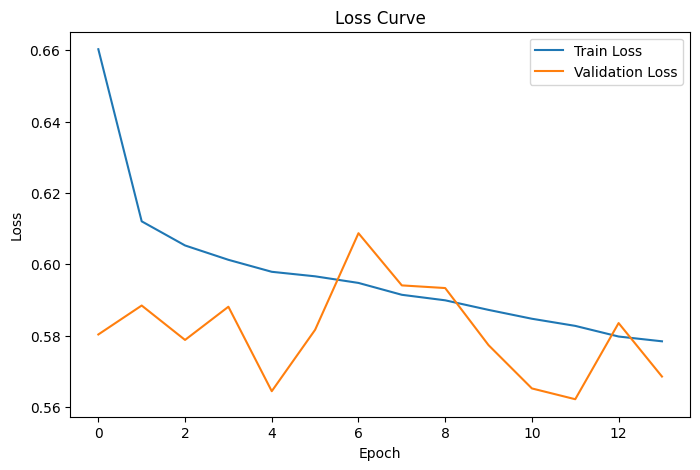

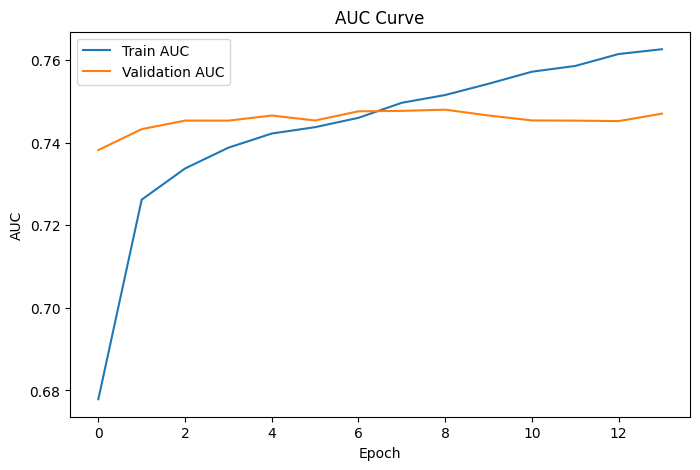

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")
plt.title("AUC Curve")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()


In [58]:
y_pred_prob = model.predict(X_test_processed).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

1922/1922 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [59]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[37530 19008]
 [ 1469  3496]]


In [60]:
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print("\nSensitivity:", round(sensitivity, 4))


Sensitivity: 0.7041


In [61]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC:", round(roc_auc, 4))

ROC AUC: 0.7483


In [62]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.66      0.79     56538
           1       0.16      0.70      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.56      0.68      0.52     61503
weighted avg       0.90      0.67      0.74     61503



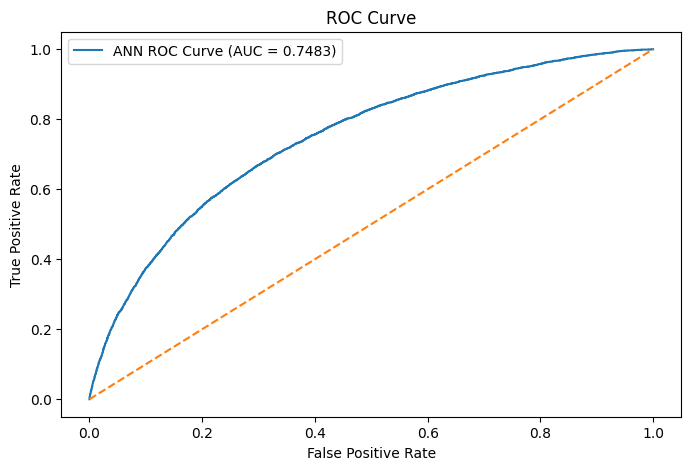

In [63]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ANN ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# **XGBOOST MODEL**

In [64]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print("\nNegative class count:", negative_count)
print("Positive class count:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 2))



Negative class count: 226148
Positive class count: 19860
scale_pos_weight: 11.39


In [65]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False
)

In [66]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

In [67]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:09:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'OWN_CAR_AGE...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [68]:
xgb_prob = model.predict_proba(X_test)[:, 1]
xgb_pred = (y_pred_prob >= 0.5).astype(int)

In [69]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[37530 19008]
 [ 1469  3496]]


In [70]:
sensitivity = recall_score(y_test, y_pred)

print("\nSensitivity:", round(sensitivity, 4))


Sensitivity: 0.7041


In [71]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC:", round(roc_auc, 4))

ROC AUC: 0.7483


In [72]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.66      0.79     56538
           1       0.16      0.70      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.56      0.68      0.52     61503
weighted avg       0.90      0.67      0.74     61503



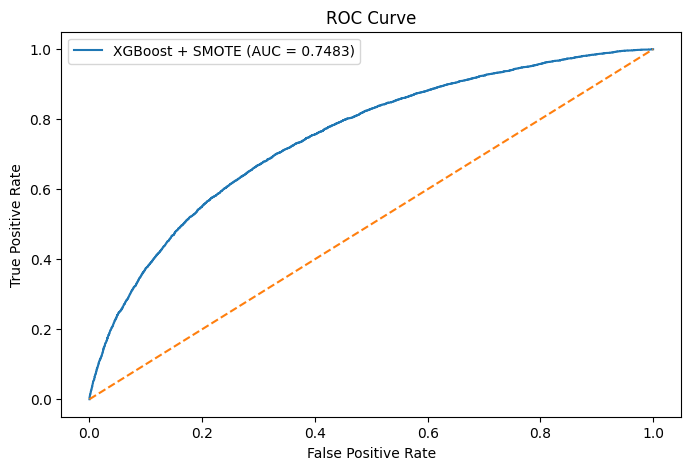

In [73]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"XGBoost + SMOTE (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [74]:
from sklearn.metrics import recall_score, roc_auc_score

def evaluate_model(name, y_test, y_pred, y_prob):
    sensitivity = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"{name}:")
    print(f"  Sensitivity: {sensitivity:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print("-" * 30)

In [77]:
evaluate_model("ANN", y_test, y_pred, y_pred_prob)
evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob)

ANN:
  Sensitivity: 0.7041
  ROC AUC: 0.7483
------------------------------
XGBoost:
  Sensitivity: 0.7041
  ROC AUC: 0.7600
------------------------------


XGBoost performed better than ANN because it matched ANN on sensitivity while achieving a higher ROC AUC, making it the stronger model overall for loan default prediction.